In [ ]:
# ============================================================================
# PAPER — Riduzione dell’ambiguità semantica tramite pseudoword multilingue
# ============================================================================

!pip -q install nltk

import nltk
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

nltk.download("wordnet")
nltk.download("omw-1.4")

from nltk.corpus import wordnet as wn

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [ ]:
# test rapido: synset inglese
print(wn.synsets("bank")[:3])

# si prendono i synset inglesi di 'bank'
syns = wn.synsets("bank")

# per ogni synset, si chiedono i lemmi italiani
italian_lemmas = set()
for s in syns:
    for l in s.lemmas(lang="ita"):
        italian_lemmas.add(l.name())

print("Italian lemmas for 'bank':", italian_lemmas)

[Synset('bank.n.01'), Synset('depository_financial_institution.n.01'), Synset('bank.n.03')]
Italian lemmas for 'bank': {'banca', 'banchina', 'salvadanaio', 'inclinare', 'banco', 'cassa', 'fila', 'inclinarsi', 'versare', 'depositare', 'dindarolo', 'riva'}


In [ ]:
# pulizia lemma (placeholder, ...)
# Per evitare artefatti lessicali presenti in WordNet (e.g. GAP, PSEUDOGAP),
# sia il vocabolario sorgente sia i candidati nella lingua target sono filtrati
# tramite vincoli ortografici e lessicali, garantendo che le pseudoword generate
# corrispondano a unità linguistiche effettive.

def is_clean_lemma(s: str) -> bool:

    if s is None:
        return False

    up = s.upper()
    if "GAP" in up: # elimina GAP!, PSEUDOGAP!, ecc.
        return False

    # rifiuta se contiene "!" o caratteri non linguistici grossi
    if "!" in s:
        return False

    # deve contenere almeno una lettera
    if not re.search(r"[A-Za-zÀ-ÖØ-öø-ÿ]", s):
        return False

    # consentiamo lettere + spazi + apostrofo + trattino
    if not re.fullmatch(r"[A-Za-zÀ-ÖØ-öø-ÿ'\- ]+", s):
        return False

    return True

In [ ]:
# costruzione di un indice veloce lemma->synset per una lingua
from collections import defaultdict

def build_lemma2synsets_index(lang: str):
    """
    Costruisce un dizionario:
      lemma (string) -> set(synset)
    per la lingua 'lang', scansionando wn.all_synsets() UNA sola volta.
    """
    idx = defaultdict(set)
    for syn in wn.all_synsets():
        for l in syn.lemmas(lang=lang):
            lemma = l.name().replace("_", " ")
            idx[lemma].add(syn)
    return idx

In [ ]:
# costruzione indici (L1, L2)
lang1 = "ita"
lang2 = "fra"

lemma2syn_lang1 = build_lemma2synsets_index(lang1)
lemma2syn_lang2 = build_lemma2synsets_index(lang2)

print("Numero lemmi in L1:", len(lemma2syn_lang1))
print("Numero lemmi in L2:", len(lemma2syn_lang2))

Numero lemmi in L1: 41855
Numero lemmi in L2: 55351


In [ ]:
# versione veloce delle funzioni usando gli indici
def synsets_of_lemma(lemma: str, lemma2syn):
    return lemma2syn.get(lemma, set())

def ambiguity_size(lemma: str, lemma2syn) -> int:
    return len(synsets_of_lemma(lemma, lemma2syn))

# test
print("Sensi banca (ita):", len(synsets_of_lemma("banca", lemma2syn_lang1)))
print("Sensi banque (fra):", len(synsets_of_lemma("banque", lemma2syn_lang2)))

Sensi banca (ita): 2
Sensi banque (fra): 17


In [ ]:
# generazione candidati y in L2 per ogni x in L1
def candidates_in_L2_from_x(x: str, lemma2syn_L1, lang2: str):
    ys = set()
    for syn in synsets_of_lemma(x, lemma2syn_L1):
        for l in syn.lemmas(lang=lang2):
            y = l.name().replace("_", " ")
            if is_clean_lemma(y): # filtro qui
                ys.add(y)
    return ys

# test
print(candidates_in_L2_from_x("banca", lemma2syn_lang1, lang2))

{'banque'}


In [ ]:
# score AmbiguityReduction e pseudowords

# POS filter
def filter_synsets_by_pos(synsets, pos: str):
    return {s for s in synsets if s.pos() == pos}

# calcolo score
def ambiguity_reduction_pos(x, y, lemma2syn_L1, lemma2syn_L2, pos=None):
    Sx = synsets_of_lemma(x, lemma2syn_L1)
    Sy = synsets_of_lemma(y, lemma2syn_L2)

    if pos is not None:
        Sx = filter_synsets_by_pos(Sx, pos)
        Sy = filter_synsets_by_pos(Sy, pos)

    if not Sx or not Sy:
        return None

    Sxy = Sx.intersection(Sy)
    if not Sxy:
        return None

    denom = len(Sx) + len(Sy)
    score = (len(Sx) + len(Sy) - 2*len(Sxy)) / denom

    return {
        "x": x, "y": y,
        "|Sx|": len(Sx), "|Sy|": len(Sy), "|Sx∩Sy|": len(Sxy),
        "AR": score,
        "shared_synsets": sorted([s.name() for s in Sxy]),
        "pseudoword": f"{x}-{y}",
        "pos": pos if pos else "all"
    }

# costruzione pseudowords filtrate per una singola x
def build_pseudowords_for_x_filtered(
    x: str,
    lemma2syn_L1,
    lemma2syn_L2,
    lang2: str,
    min_shared=2,
    pos="n",          # "n"=nouns, "v"=verbs, None=all
    max_sy=30         # evita y iper-ambigui
):
    out = []
    # scarta x se non pulito
    if not is_clean_lemma(x):
        return out

    # genera candidati y in L2
    ys = candidates_in_L2_from_x(x, lemma2syn_L1, lang2)
    for y in ys:
        if not is_clean_lemma(y):
            continue

        r = ambiguity_reduction_pos(x, y, lemma2syn_L1, lemma2syn_L2, pos=pos)
        if r is None:
            continue

        # filtri qualità
        if r["|Sx∩Sy|"] < min_shared:
            continue
        if r["|Sy|"] > max_sy:
            continue

        out.append(r)

    # ordina per AR decrescente
    out.sort(key=lambda d: d["AR"], reverse=True)
    return out

# test
print(build_pseudowords_for_x_filtered("banca", lemma2syn_lang1, lemma2syn_lang2, lang2)[:3])

[{'x': 'banca', 'y': 'banque', '|Sx|': 2, '|Sy|': 10, '|Sx∩Sy|': 2, 'AR': 0.6666666666666666, 'shared_synsets': ['bank.n.09', 'depository_financial_institution.n.01'], 'pseudoword': 'banca-banque', 'pos': 'n'}]


In [ ]:
# selezione vocabolario 'pulito' + limiti di ambiguità
def select_polysemous_vocabulary_clean(lemma2syn_L1, min_senses=2, max_senses=25, max_words=500):
    xs = []
    for x, syns in lemma2syn_L1.items():
        k = len(syns)
        if k < min_senses or k > max_senses:
            continue
        if not is_clean_lemma(x):
            continue
        xs.append(x)

    # ordina: più ambigue prima (ma entro max_senses)
    xs.sort(key=lambda x: len(lemma2syn_L1[x]), reverse=True)
    return xs[:max_words]

# test
X = select_polysemous_vocabulary_clean(lemma2syn_lang1, min_senses=2, max_senses=20, max_words=300)
print("Numero parole selezionate (pulite):", len(X))
print("Esempi:", X[:30])
print("Max ambiguità in X:", max(len(lemma2syn_lang1[x]) for x in X))

Numero parole selezionate (pulite): 300
Esempi: ['andare', 'molto', 'fine', 'portare', 'lasciare', 'tagliare', 'dare', 'controllare', 'solo', 'campo', 'stare', 'chiaro', 'grande', 'proprio', 'base', 'vita', 'apertura', 'modello', 'gioco', 'peso', 'asprezza', 'vedere', 'cadere', 'aprire', 'buono', 'giusto', 'prima', 'cosa', 'tempo', 'controllo']
Max ambiguità in X: 19


In [ ]:
# generazione pseudowords per tutte le x e creazione tabella (DataFrame)
rows = []
for x in X:
    pws = build_pseudowords_for_x_filtered(
        x,
        lemma2syn_lang1,
        lemma2syn_lang2,
        lang2,
        min_shared=2,
        pos="n",
        max_sy=30
    )
    rows.extend(pws)

df = pd.DataFrame(rows)

print("Numero pseudowords:", len(df))
df.head(20)

Numero pseudowords: 467


,x,y,|Sx|,|Sy|,|Sx∩Sy|,AR,shared_synsets,pseudoword,pos
0,fine,mort,16,14,2,0.866667,"[death.n.04, end.n.06]",fine-mort,n
1,fine,dernier,16,10,2,0.846154,"[end.n.03, stopping_point.n.01]",fine-dernier,n
2,fine,extrémité,16,10,2,0.846154,"[end.n.01, end.n.02]",fine-extrémité,n
3,fine,issue,16,9,2,0.840000,"[end.n.02, end.n.05]",fine-issue,n
4,fine,usage,16,9,2,0.840000,"[determination.n.02, function.n.02]",fine-usage,n
5,fine,bout,16,13,3,0.793103,"[end.n.01, end.n.02, ending.n.04]",fine-bout,n
6,fine,terme,16,19,4,0.771429,"[end.n.02, end.n.03, end.n.05, end.n.06]",fine-terme,n
7,fine,conclusion,16,10,3,0.769231,"[ending.n.04, stopping_point.n.01, termination...",fine-conclusion,n
8,fine,but,16,7,3,0.739130,"[aim.n.03, goal.n.01, purpose.n.01]",fine-but,n
9,fine,objectif,16,9,4,0.680000,"[aim.n.02, aim.n.03, goal.n.01, purpose.n.01]",fine-objectif,n


In [ ]:
# riduzione media di ambiguità: confronto prima/dopo

df["amb_x"] = df["|Sx|"]
df["amb_y"] = df["|Sy|"]
df["amb_pw"] = df["|Sx∩Sy|"]

# riduzioni assolute
df["delta_x_to_pw"] = df["amb_x"] - df["amb_pw"]
df["delta_y_to_pw"] = df["amb_y"] - df["amb_pw"]

# riduzioni relative (0..1)
df["rel_red_x"] = df["delta_x_to_pw"] / df["amb_x"]
df["rel_red_y"] = df["delta_y_to_pw"] / df["amb_y"]

print("N pseudowords:", len(df))
print("AR medio:", df["AR"].mean())
print("AR mediano:", df["AR"].median())

print("\nAmbiguità media:")
print("  x (L1):", df["amb_x"].mean())
print("  y (L2):", df["amb_y"].mean())
print("  pseudoword:", df["amb_pw"].mean())

print("\nRiduzione media assoluta:")
print("  x -> pw:", df["delta_x_to_pw"].mean())
print("  y -> pw:", df["delta_y_to_pw"].mean())

print("\nRiduzione media relativa:")
print("  x -> pw:", df["rel_red_x"].mean())
print("  y -> pw:", df["rel_red_y"].mean())

print("\n% con riduzione effettiva (delta > 0):")
print("  x:", (df["delta_x_to_pw"] > 0).mean())
print("  y:", (df["delta_y_to_pw"] > 0).mean())


N pseudowords: 467
AR medio: 0.6577114331490267
AR mediano: 0.6923076923076923

Ambiguità media:
  x (L1): 9.244111349036402
  y (L2): 9.820128479657388
  pseudoword: 3.147751605995717

Riduzione media assoluta:
  x -> pw: 6.0963597430406855
  y -> pw: 6.67237687366167

Riduzione media relativa:
  x -> pw: 0.6460788438304498
  y -> pw: 0.5930254739118808

% con riduzione effettiva (delta > 0):
  x: 0.9957173447537473
  y: 0.9486081370449678


In [ ]:
# top-20 pseudowords 'migliori'
df_sorted = df.sort_values(
    ["rel_red_x", "|Sx∩Sy|", "AR"],
    ascending=[False, False, False]
)

top20 = df_sorted.head(20)[
    ["pseudoword", "x", "y", "pos", "|Sx|", "|Sy|", "|Sx∩Sy|", "AR", "rel_red_x", "shared_synsets"]
]
top20

,pseudoword,x,y,pos,|Sx|,|Sy|,|Sx∩Sy|,AR,rel_red_x,shared_synsets
0,fine-mort,fine,mort,n,16,14,2,0.866667,0.875000,"[death.n.04, end.n.06]"
1,fine-dernier,fine,dernier,n,16,10,2,0.846154,0.875000,"[end.n.03, stopping_point.n.01]"
2,fine-extrémité,fine,extrémité,n,16,10,2,0.846154,0.875000,"[end.n.01, end.n.02]"
3,fine-issue,fine,issue,n,16,9,2,0.840000,0.875000,"[end.n.02, end.n.05]"
4,fine-usage,fine,usage,n,16,9,2,0.840000,0.875000,"[determination.n.02, function.n.02]"
11,campo-domaine,campo,domaine,n,15,18,2,0.878788,0.866667,"[discipline.n.01, sphere.n.01]"
12,campo-terrain,campo,terrain,n,15,8,2,0.826087,0.866667,"[field.n.03, playing_field.n.02]"
13,campo-camp,campo,camp,n,15,8,2,0.826087,0.866667,"[camp.n.01, camp.n.02]"
14,campo-camper,campo,camper,n,15,7,2,0.818182,0.866667,"[camp.n.01, camp.n.02]"
15,campo-orbite,campo,orbite,n,15,5,2,0.800000,0.866667,"[scope.n.01, sphere.n.01]"


In [ ]:
# analisi per lemma sorgente x (quali parole migliorano di più)
by_x = (df.groupby("x")
          .agg(
              n_pairs=("pseudoword", "count"), # numero di pseudowords prodotte
              mean_AR=("AR", "mean"), # AR medio
              mean_amb_x=("amb_x", "mean"), # ambiguità media x
              mean_amb_pw=("amb_pw", "mean"), # ambiguità media pseudoword
              mean_rel_red_x=("rel_red_x", "mean"), # riduzione relativa media
              max_rel_red_x=("rel_red_x", "max"), # riduzione relativa massima
          )
          .sort_values(["mean_rel_red_x", "n_pairs"], ascending=False)
       )

by_x.head(20)

,n_pairs,mean_AR,mean_amb_x,mean_amb_pw,mean_rel_red_x,max_rel_red_x
x,,,,,,
asprezza,5,0.771111,14.0,2.000000,0.857143,0.857143
fondo,1,0.833333,12.0,2.000000,0.833333,0.833333
bontà,4,0.730325,11.0,2.000000,0.818182,0.818182
delicatezza,1,0.714286,11.0,2.000000,0.818182,0.818182
banda,3,0.792920,10.0,2.000000,0.800000,0.800000
canto,2,0.802353,10.0,2.000000,0.800000,0.800000
guardia,2,0.779762,10.0,2.000000,0.800000,0.800000
cenno,1,0.692308,10.0,2.000000,0.800000,0.800000
punto,1,0.851852,10.0,2.000000,0.800000,0.800000


In [ ]:
# Joint Reduction Score (JRS)
# misura quanta ambiguità riducono entrambe le lingue, non solo 'quanto taglia'
# valori vicino allo 0 indicano una riduzione solo in una lingua oppure intersezione quasi totale
# valori vicino a 1 indicano una forte riduzione in entrambe le lingue

df["jrs"] = (
    (df["|Sx|"] - df["|Sx∩Sy|"]) / df["|Sx|"]
) * (
    (df["|Sy|"] - df["|Sx∩Sy|"]) / df["|Sy|"]
)

df.sort_values("jrs", ascending=False).head(10)[
    ["pseudoword", "|Sx|", "|Sy|", "|Sx∩Sy|", "AR", "jrs"]
]

,pseudoword,|Sx|,|Sy|,|Sx∩Sy|,AR,jrs
29,gioco-partie,14,24,2,0.894737,0.785714
11,campo-domaine,15,18,2,0.878788,0.770370
25,modello-forme,14,19,2,0.878788,0.766917
49,passo-passage,13,19,2,0.875000,0.757085
0,fine-mort,16,14,2,0.866667,0.750000
66,corona-milieu,12,18,2,0.866667,0.740741
94,deposito-réserve,11,19,2,0.866667,0.732057
150,banda-groupe,10,22,2,0.875000,0.727273
57,terra-pays,13,14,2,0.851852,0.725275
50,passo-mesure,13,13,2,0.846154,0.715976


In [ ]:
# confronto tra AR e jrs
df[["AR", "jrs"]].describe()

,AR,jrs
count,467.000000,467.000000
mean,0.657711,0.392867
std,0.151722,0.209486
min,0.176471,0.000000
25%,0.583333,0.234432
50%,0.692308,0.413265
75%,0.764706,0.562500
max,0.894737,0.785714


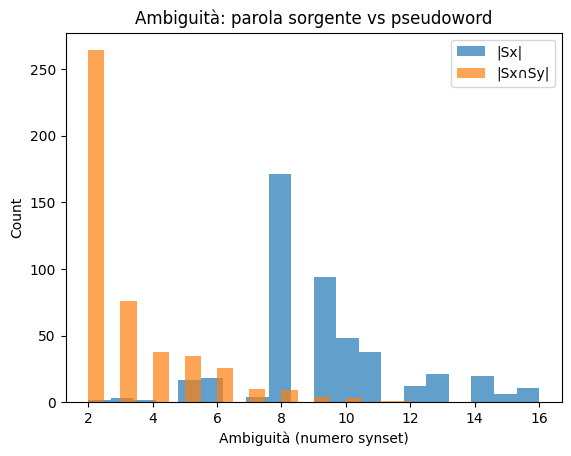

In [ ]:
# confronto ambiguità: x vs pseudoword
plt.figure()
plt.hist(df["amb_x"], bins=20, alpha=0.7, label="|Sx|")
plt.hist(df["amb_pw"], bins=20, alpha=0.7, label="|Sx∩Sy|")
plt.xlabel("Ambiguità (numero synset)")
plt.ylabel("Count")
plt.legend()
plt.title("Ambiguità: parola sorgente vs pseudoword")
plt.show()

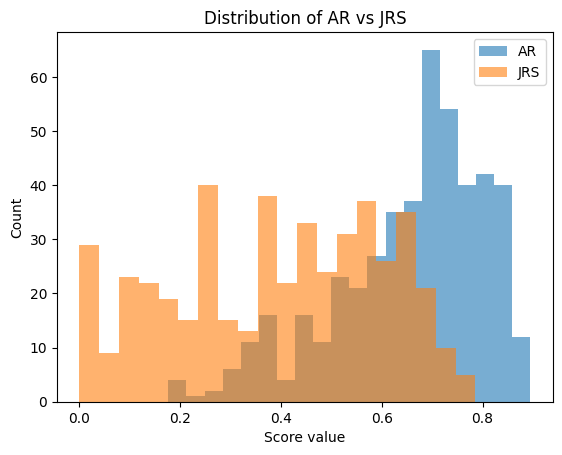

In [ ]:
# distribuzioni sovrapposte AR vs JRS
plt.figure()
plt.hist(df["AR"], bins=20, alpha=0.6, label="AR")
plt.hist(df["jrs"], bins=20, alpha=0.6, label="JRS")
plt.xlabel("Score value")
plt.ylabel("Count")
plt.legend()
plt.title("Distribution of AR vs JRS")
plt.show()

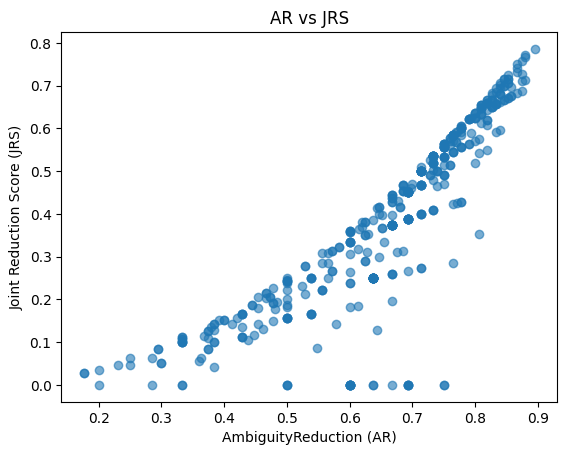

In [ ]:
# scatter AR vs JRS
plt.figure()
plt.scatter(df["AR"], df["jrs"], alpha=0.6)
plt.xlabel("AmbiguityReduction (AR)")
plt.ylabel("Joint Reduction Score (JRS)")
plt.title("AR vs JRS")
plt.show()